# Sampling, Reconstruction, and Aliasing
### A Theoretical and Simulation-Based Study

**Author:** Iyeba Alpha Kallon  
**Date:** February 2026  
**Institution:** Fourah Bay College, University of Sierra Leone  

---

This notebook implements the simulations accompanying the paper:
*"Sampling, Reconstruction, and Aliasing: A Theoretical and Simulation-Based Study"*

Three experiments are presented:
1. Spectral replication under proper sampling
2. Aliasing under undersampling
3. Signal reconstruction via Whittaker-Shannon interpolation

**Dependencies:** `numpy`, `matplotlib`, `scipy`  
**GitHub:** [https://github.com/Iyeba-Kallon/sampling-reconstruction-aliasing.git]

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Plot settings
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True

In [2]:
# ─── Signal Parameters ─────
f0 = 50          # Signal frequency (Hz)
B  = 50          # Bandwidth (Hz) - signal has one component at f0
fs_good = 500    # Sampling frequency - satisfies Nyquist (fs >> 2B)
fs_bad  = 60     # Sampling frequency - violates Nyquist (fs < 2B)
T  = 1.0         # Duration (seconds)

# ─Continuous-time signal (high resolution = "analog")
t_cont = np.linspace(0, T, 10000, endpoint=False)
x_cont = np.cos(2 * np.pi * f0 * t_cont)

print(f"Signal frequency     : {f0} Hz")
print(f"Nyquist rate         : {2*f0} Hz")
print(f"Good sampling rate   : {fs_good} Hz → {'OK' if fs_good >= 2*f0 else 'ALIASING'}")
print(f"Bad sampling rate    : {fs_bad} Hz → {'OK' if fs_bad >= 2*f0 else 'ALIASING'}")

Signal frequency     : 50 Hz
Nyquist rate         : 100 Hz
Good sampling rate   : 500 Hz → OK
Bad sampling rate    : 60 Hz → ALIASING


In [3]:
# ─── Discrete samples ────────────────────────────────────────────
# Good sampling (no aliasing)
t_good = np.arange(0, T, 1/fs_good)
x_good = np.cos(2 * np.pi * f0 * t_good)

# Bad sampling (aliasing)
t_bad = np.arange(0, T, 1/fs_bad)
x_bad = np.cos(2 * np.pi * f0 * t_bad)

print(f"Continuous signal points : {len(t_cont)}")
print(f"Good samples (500 Hz)    : {len(t_good)}")
print(f"Bad samples  (60 Hz)     : {len(t_bad)}")

Continuous signal points : 10000
Good samples (500 Hz)    : 500
Bad samples  (60 Hz)     : 60


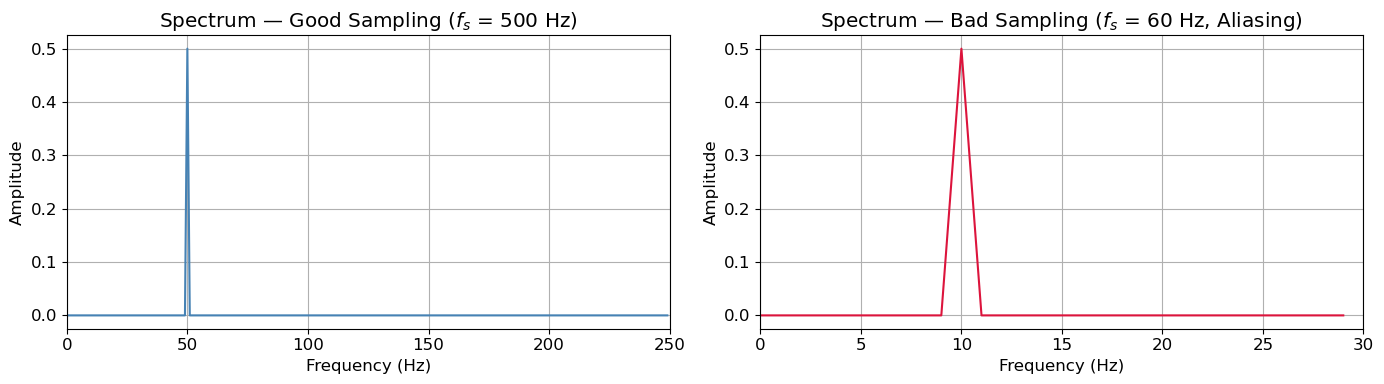

fig1_spectral_replication.png saved!


In [4]:
# ─── Figure 1: Spectral Replication ──────────────────────────────
def plot_spectrum(t, x, fs, title, color):
    N = len(x)
    freqs = np.fft.fftfreq(N, 1/fs)
    spectrum = np.abs(np.fft.fft(x)) / N
    
    # Only plot positive frequencies
    pos_mask = freqs >= 0
    freqs = freqs[pos_mask]
    spectrum = spectrum[pos_mask]
    
    plt.plot(freqs, spectrum, color=color)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.xlim(0, fs/2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plt.sca(axes[0])
plot_spectrum(t_good, x_good, fs_good,
    f"Spectrum — Good Sampling ($f_s$ = {fs_good} Hz)", "steelblue")

plt.sca(axes[1])
plot_spectrum(t_bad, x_bad, fs_bad,
    f"Spectrum — Bad Sampling ($f_s$ = {fs_bad} Hz, Aliasing)", "crimson")

plt.tight_layout()
plt.savefig("fig1_spectral_replication.png", dpi=150, bbox_inches='tight')
plt.show()
print("fig1_spectral_replication.png saved!")

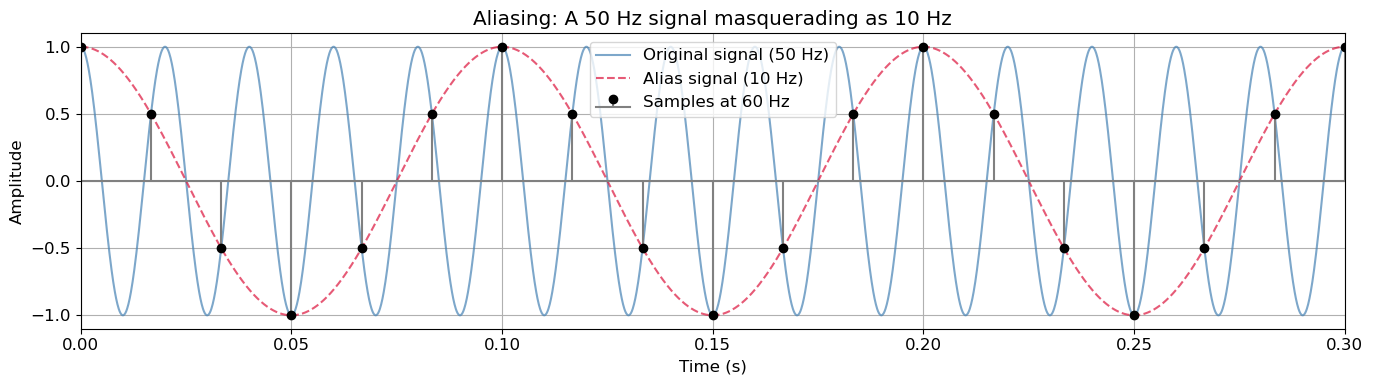

fig2_aliasing.png saved!


In [5]:
# ─── Figure 2: Aliasing in Time Domain ───────────────────────────
# The alias frequency
f_alias = abs(f0 - round(f0/fs_bad) * fs_bad)
t_alias = np.linspace(0, T, 10000, endpoint=False)
x_alias = np.cos(2 * np.pi * f_alias * t_alias)

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(t_cont, x_cont, 'steelblue', linewidth=1.5,
        label=f'Original signal ({f0} Hz)', alpha=0.7)
ax.plot(t_alias, x_alias, 'crimson', linewidth=1.5,
        linestyle='--', label=f'Alias signal ({f_alias} Hz)', alpha=0.7)
ax.stem(t_bad, x_bad, linefmt='gray', markerfmt='ko',
        basefmt='gray', label=f'Samples at {fs_bad} Hz')

ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title("Aliasing: A 50 Hz signal masquerading as 10 Hz")
ax.legend()
ax.set_xlim(0, 0.3)

plt.tight_layout()
plt.savefig("fig2_aliasing.png", dpi=150, bbox_inches='tight')
plt.show()
print("fig2_aliasing.png saved!")

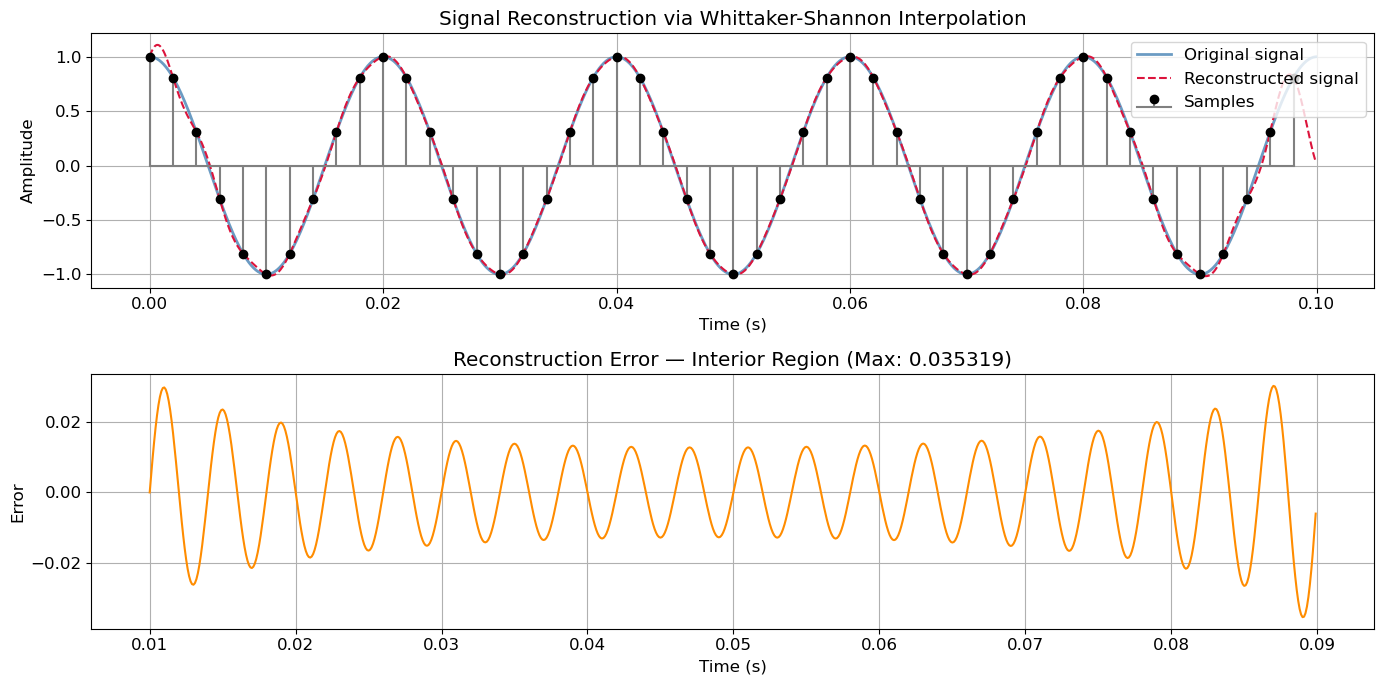

fig3_reconstruction.png saved!


In [7]:
# ─── Figure 3: Reconstruction via Sinc Interpolation ─────────────
def sinc_interpolate(t_samples, x_samples, t_reconstruct, fs):
    """Whittaker-Shannon interpolation formula"""
    Ts = 1 / fs
    result = np.zeros(len(t_reconstruct))
    for n, (tn, xn) in enumerate(zip(t_samples, x_samples)):
        result += xn * np.sinc((t_reconstruct - tn) / Ts)
    return result

# Reconstruct from good samples
t_recon = np.linspace(0, 0.1, 1000, endpoint=False)
t_good_short = t_good[t_good < 0.1]
x_good_short = x_good[t_good < 0.1]
x_recon = sinc_interpolate(t_good_short, x_good_short, t_recon, fs_good)

# Original for comparison
x_orig_short = np.cos(2 * np.pi * f0 * t_recon)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Top plot - overlay
axes[0].plot(t_recon, x_orig_short, 'steelblue',
             linewidth=2, label='Original signal', alpha=0.8)
axes[0].plot(t_recon, x_recon, 'crimson',
             linewidth=1.5, linestyle='--', label='Reconstructed signal')
axes[0].stem(t_good_short, x_good_short, linefmt='gray',
             markerfmt='ko', basefmt='gray', label='Samples')
axes[0].set_title("Signal Reconstruction via Whittaker-Shannon Interpolation")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].legend()


# Bottom plot - error (trim edges to avoid boundary artifacts)
trim = 100  # ignore first and last 100 points
error = x_orig_short[trim:-trim] - x_recon[trim:-trim]
t_trim = t_recon[trim:-trim]

axes[1].plot(t_trim, error, 'darkorange', linewidth=1.5)
axes[1].set_title(f"Reconstruction Error — Interior Region (Max: {np.max(np.abs(error)):.6f})")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Error")

plt.tight_layout()
plt.savefig("fig3_reconstruction.png", dpi=150, bbox_inches='tight')
plt.show()
print("fig3_reconstruction.png saved!")